In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_height, img_width = 150, 150  
batch_size = 64
train_data_dir = "E:\\imagenette2-160\\imagenette2-160\\train"
validation_data_dir = "E:\\imagenette2-160\\imagenette2-160\\val"

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation data generator
val_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'  # For multi-class classification
)

val_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 9469 images belonging to 10 classes.
Found 3925 images belonging to 10 classes.


In [2]:
from keras.models import Sequential, Model
from keras.layers import Conv2D, Input, Dropout, Activation, Dense, MaxPooling2D, Flatten, GlobalAveragePooling2D
from keras.optimizers import Adadelta
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from keras.models import load_model
from keras.applications.inception_v3 import InceptionV3

In [3]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation='relu')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(10, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [4]:
for layer in transfer_learning_model.layers[:280]:
    layer.trainable = False
for layer in transfer_learning_model.layers[280:]:
    layer.trainable = True

In [5]:
history_relu=transfer_learning_model.fit(train_generator, batch_size=64, epochs=20, verbose=1, validation_data=val_generator)

Epoch 1/20


C:\Users\Rishi Chaitanya\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


148/148 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.3545 - loss: 1.9309 - val_accuracy: 0.8675 - val_loss: 0.5730
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 572s 4s/step - accuracy: 0.7806 - loss: 0.8580 - val_accuracy: 0.8983 - val_loss: 0.4036
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.8287 - loss: 0.6188 - val_accuracy: 0.9101 - val_loss: 0.3308
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.8595 - loss: 0.5086 - val_accuracy: 0.9159 - val_loss: 0.2889
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.8656 - loss: 0.4409 - val_accuracy: 0.9205 - val_loss: 0.2620
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.8829 - loss: 0.3993 - val_accuracy: 0.9264 - val_loss: 0.2424
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.8818 - loss: 0.3807 - val_accuracy: 0.9287 - val_loss: 0.2333
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 336s 2s/step - accuracy: 0.8858 - loss: 0.3691 - val_accuracy: 0.931

In [6]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation=tf.keras.activations.leaky_relu)(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(10, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [7]:
for layer in transfer_learning_model.layers[:280]:
    layer.trainable = False
for layer in transfer_learning_model.layers[280:]:
    layer.trainable = True

In [8]:
history_leaky=transfer_learning_model.fit(train_generator, batch_size=64, epochs=20, verbose=1, validation_data=val_generator)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.3906 - loss: 1.8334 - val_accuracy: 0.8736 - val_loss: 0.5037
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.7983 - loss: 0.8031 - val_accuracy: 0.9019 - val_loss: 0.3711
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.8360 - loss: 0.5851 - val_accuracy: 0.9098 - val_loss: 0.3072
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8646 - loss: 0.4700 - val_accuracy: 0.9152 - val_loss: 0.2747
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.8719 - loss: 0.4306 - val_accuracy: 0.9190 - val_loss: 0.2525
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8779 - loss: 0.4018 - val_accuracy: 0.9231 - val_loss: 0.2377
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.8784 - loss: 0.3786 - val_accuracy: 0.9264 - val_loss: 0.2227
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8848 - loss: 0.3638 - val_accu

In [9]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation='elu')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(10, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [10]:
for layer in transfer_learning_model.layers[:280]:
    layer.trainable = False
for layer in transfer_learning_model.layers[280:]:
    layer.trainable = True

In [11]:
history_elu=transfer_learning_model.fit(train_generator, batch_size=64, epochs=20, verbose=1, validation_data=val_generator)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.4002 - loss: 1.8192 - val_accuracy: 0.8803 - val_loss: 0.4430
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.8044 - loss: 0.7006 - val_accuracy: 0.9065 - val_loss: 0.3311
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 311s 2s/step - accuracy: 0.8513 - loss: 0.5226 - val_accuracy: 0.9167 - val_loss: 0.2904
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.8578 - loss: 0.4596 - val_accuracy: 0.9223 - val_loss: 0.2573
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.8770 - loss: 0.3998 - val_accuracy: 0.9259 - val_loss: 0.2390
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.8859 - loss: 0.3747 - val_accuracy: 0.9302 - val_loss: 0.2261
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 310s 2s/step - accuracy: 0.8832 - loss: 0.3681 - val_accuracy: 0.9310 - val_loss: 0.2153
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.8911 - loss: 0.3364 - val_accu

In [12]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation='swish')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(10, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [13]:
for layer in transfer_learning_model.layers[:280]:
    layer.trainable = False
for layer in transfer_learning_model.layers[280:]:
    layer.trainable = True

In [14]:
history_swish=transfer_learning_model.fit(train_generator, batch_size=64, epochs=20, verbose=1, validation_data=val_generator)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.4177 - loss: 1.7947 - val_accuracy: 0.8782 - val_loss: 0.5095
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.7995 - loss: 0.8228 - val_accuracy: 0.9014 - val_loss: 0.3866
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8387 - loss: 0.5944 - val_accuracy: 0.9116 - val_loss: 0.3204
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.8616 - loss: 0.4726 - val_accuracy: 0.9162 - val_loss: 0.2819
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.8775 - loss: 0.4259 - val_accuracy: 0.9210 - val_loss: 0.2585
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.8849 - loss: 0.3974 - val_accuracy: 0.9246 - val_loss: 0.2404
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.8913 - loss: 0.3756 - val_accuracy: 0.9289 - val_loss: 0.2282
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8854 - loss: 0.3714 - val_accu

In [15]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation='mish')(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(10, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [16]:
for layer in transfer_learning_model.layers[:280]:
    layer.trainable = False
for layer in transfer_learning_model.layers[280:]:
    layer.trainable = True

In [17]:
history_mish=transfer_learning_model.fit(train_generator, batch_size=64, epochs=20, verbose=1, validation_data=val_generator)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.3687 - loss: 1.9260 - val_accuracy: 0.8757 - val_loss: 0.4948
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.8102 - loss: 0.7796 - val_accuracy: 0.9017 - val_loss: 0.3789
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.8473 - loss: 0.5604 - val_accuracy: 0.9129 - val_loss: 0.3167
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.8580 - loss: 0.4690 - val_accuracy: 0.9187 - val_loss: 0.2814
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 326s 2s/step - accuracy: 0.8733 - loss: 0.4326 - val_accuracy: 0.9243 - val_loss: 0.2560
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8750 - loss: 0.4063 - val_accuracy: 0.9241 - val_loss: 0.2425
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.8821 - loss: 0.3828 - val_accuracy: 0.9297 - val_loss: 0.2322
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.8862 - loss: 0.3692 - val_accu

In [19]:
from loglu import LogLU

In [20]:
base_model = InceptionV3(weights='imagenet', include_top=False)

transfer_learning_arch = base_model.output
transfer_learning_arch = GlobalAveragePooling2D()(transfer_learning_arch)
transfer_learning_arch = Dense(512, activation=LogLU())(transfer_learning_arch)
transfer_learning_arch = Dropout(0.4)(transfer_learning_arch)
predictions = Dense(10, activation='softmax')(transfer_learning_arch)

transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)

In [21]:
for layer in transfer_learning_model.layers[:280]:
    layer.trainable = False
for layer in transfer_learning_model.layers[280:]:
    layer.trainable = True

In [22]:
transfer_learning_model.compile(loss='categorical_crossentropy', optimizer=Adadelta(learning_rate=0.01), metrics=['accuracy'])

In [23]:
history=transfer_learning_model.fit(train_generator, batch_size=64, epochs=20, verbose=1, validation_data=val_generator)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 485s 3s/step - accuracy: 0.4087 - loss: 1.7804 - val_accuracy: 0.8879 - val_loss: 0.4297
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 703s 5s/step - accuracy: 0.8057 - loss: 0.7146 - val_accuracy: 0.9060 - val_loss: 0.3358
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.8430 - loss: 0.5368 - val_accuracy: 0.9172 - val_loss: 0.2893
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.8615 - loss: 0.4562 - val_accuracy: 0.9205 - val_loss: 0.2621
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 342s 2s/step - accuracy: 0.8737 - loss: 0.4162 - val_accuracy: 0.9269 - val_loss: 0.2424
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.8793 - loss: 0.3872 - val_accuracy: 0.9294 - val_loss: 0.2305
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.8900 - loss: 0.3705 - val_accuracy: 0.9320 - val_loss: 0.2211
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 408s 3s/step - accuracy: 0.8941 - loss: 0.3342 - val_accu

In [25]:
transfer_learning_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)    │ (None, None, None, 3)     │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_564 (Conv2D)           │ (None, None, None, 32)    │             864 │ input_layer_6[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_564       │ (None, None, None, 32)    │              96 │ conv2d_564[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_564 (Activation)   │ (None, None, None, 32)    │               0 │ batch_normalization_564[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_565 (Conv2D)           │ (None, None, None, 32)    │           9,216 │ activation_564[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_565       │ (None, None, None, 32)    │              96 │ conv2d_565[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_565 (Activation)   │ (None, None, None, 32)    │               0 │ batch_normalization_565[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_566 (Conv2D)           │ (None, None, None, 64)    │          18,432 │ activation_565[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_566       │ (None, None, None, 64)    │             192 │ conv2d_566[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_566 (Activation)   │ (None, None, None, 64)    │               0 │ batch_normalization_566[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_24              │ (None, None, None, 64)    │               0 │ activation_566[0][0]       │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_567 (Conv2D)           │ (None, None, None, 80)    │           5,120 │ max_pooling2d_24[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_567       │ (None, None, None, 80)    │             240 │ conv2d_567[0][0]           │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ activation_567 (Activation)   │ (None, None, None, 80)    │               0 │ batch_normalization_567[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_568 (Conv2D)           │ (None, None, None, 192)   │         138,24

 Total params: 37,112,512 (141.57 MB)

 Trainable params: 7,127,754 (27.19 MB)

 Non-trainable params: 15,729,248 (60.00 MB)

 Optimizer params: 14,255,510 (54.38 MB)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

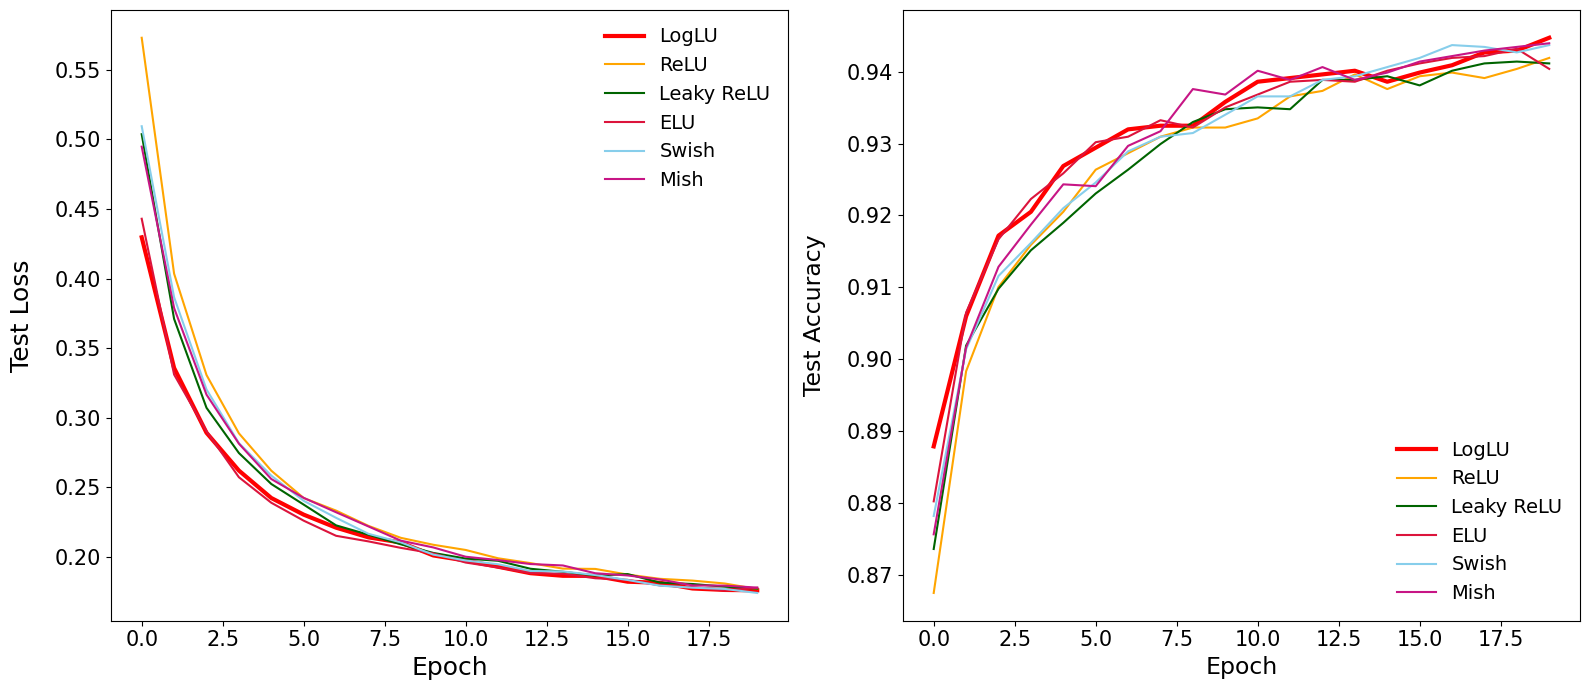

In [24]:
plt.figure(figsize=(16, 7))

plt.subplot(1, 2, 1)
plt.plot(history.history['val_loss'], label='LogLU', color='red', linewidth=3)
plt.plot(history_relu.history['val_loss'],label='ReLU', color='orange')
plt.plot(history_leaky.history['val_loss'],label='Leaky ReLU', color='darkgreen')
plt.plot(history_elu.history['val_loss'], label='ELU', color='crimson')
plt.plot(history_swish.history['val_loss'], label='Swish', color='skyblue')
plt.plot(history_mish.history['val_loss'], label='Mish', color='mediumvioletred')
plt.ylabel('Test Loss', fontsize=18, labelpad=15)
plt.xlabel('Epoch', fontsize=18)
plt.legend(fontsize=14,loc='upper right',frameon=False)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)


plt.subplot(1, 2, 2)
plt.plot(history.history['val_accuracy'], label='LogLU', color='red', linewidth=3)
plt.plot(history_relu.history['val_accuracy'],label='ReLU', color='orange')
plt.plot(history_leaky.history['val_accuracy'],label='Leaky ReLU', color='darkgreen')
plt.plot(history_elu.history['val_accuracy'], label='ELU', color='crimson')
plt.plot(history_swish.history['val_accuracy'], label='Swish', color='skyblue')
plt.plot(history_mish.history['val_accuracy'], label='Mish', color='mediumvioletred')
plt.ylabel('Test Accuracy', fontsize=17, labelpad=15)
plt.xlabel('Epoch', fontsize=17)
plt.legend(fontsize=14,loc='lower right',frameon=False)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()

plt.savefig('Imagenette InceptionV3.png', dpi=500)
plt.show()